# Air Quality Assessment and AQI Forecasting Using Machine Learning
## Notebook 01: Professional Exploratory Data Analysis & Time Series Diagnostics
---
### Objectives:
1. Profile the raw Nehru Nagar, Kanpur air quality dataset.
2. Conduct missing value, duplicate, and outlier analyses.
3. Perform advanced time-series diagnostics: Stationarity (ADF test), Autocorrelation (ACF/PACF), and Seasonal Decomposition.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
print('Check: Essential time-series libraries imported.')

### Load Dataset
We load the raw Excel file containing pollutant concentrations.

In [2]:
possible_paths = [
    '../data/raw/nehru-nagar, kanpur-air-quality (1).xlsx',
    'data/raw/nehru-nagar, kanpur-air-quality (1).xlsx'
]
df_raw = None
for path in possible_paths:
    if os.path.exists(path):
        df_raw = pd.read_excel(path)
        print(f'Check: Loaded raw dataset from: {path}')
        break

if df_raw is None:
    raise FileNotFoundError('Raw dataset file could not be found.')

print(f'Dataset Dimensions: {df_raw.shape}')
display(df_raw.head())

Check: Loaded raw dataset from: ../data/raw/nehru-nagar, kanpur-air-quality (1).xlsx
Dataset Dimensions: (3977, 7)


,Date,pm2.5,pm10,O3,NO2,SO2,co
0,2026-06-01,98.0,49.0,16.0,16.0,4.0,8.0
1,2026-06-02,107.0,47.0,15.0,15.0,4.0,8.0
2,2026-06-03,105.0,60.0,17.0,15.0,4.0,8.0
3,2026-06-04,133.0,36.0,19.0,15.0,4.0,8.0
4,2026-06-05,83.0,58.0,19.0,15.0,4.0,9.0


### Dataset Profiling
We inspect datatypes, memory footprint, duplicate dates, and basic statistics.

In [3]:
print('--- Column Data Types ---')
print(df_raw.dtypes)

print('\n--- Duplicate Date Count ---')
df_raw['Date'] = pd.to_datetime(df_raw['Date'])
print(df_raw['Date'].duplicated().sum())

print('\n--- Statistical Summary ---')
display(df_raw.describe())

--- Column Data Types ---
Date     datetime64[us]
pm2.5           float64
pm10            float64
O3              float64
NO2             float64
SO2             float64
co              float64
dtype: object

--- Duplicate Date Count ---
0

--- Statistical Summary ---


,Date,pm2.5,pm10,O3,NO2,SO2,co
count,3976,3712.000000,1748.000000,3756.000000,3505.000000,3622.000000,3136.000000
mean,2020-11-08 05:48:02.897384,152.531519,72.022883,19.316028,26.422539,5.781612,15.835778
min,2015-01-01 00:00:00,26.000000,6.000000,1.000000,1.000000,1.000000,1.000000
25%,2017-12-15 18:00:00,101.000000,47.000000,8.000000,15.000000,3.000000,9.000000
50%,2020-12-09 12:00:00,140.000000,64.000000,16.000000,21.000000,4.000000,12.000000
75%,2023-09-13 06:00:00,177.000000,87.000000,27.000000,34.000000,7.000000,19.000000
max,2026-06-23 00:00:00,688.000000,549.000000,390.000000,123.000000,49.000000,100.000000
std,NaN,75.837148,43.596048,17.115134,17.712645,5.102925,11.015408


### Missing Values Spatial Analysis
We audit missingness and visualize gaps using heatmaps.

--- Percentage of Missing Values ---
Date      0.025145
pm2.5     6.663314
pm10     56.047272
O3        5.556952
NO2      11.868242
SO2       8.926326
co       21.146593
dtype: float64


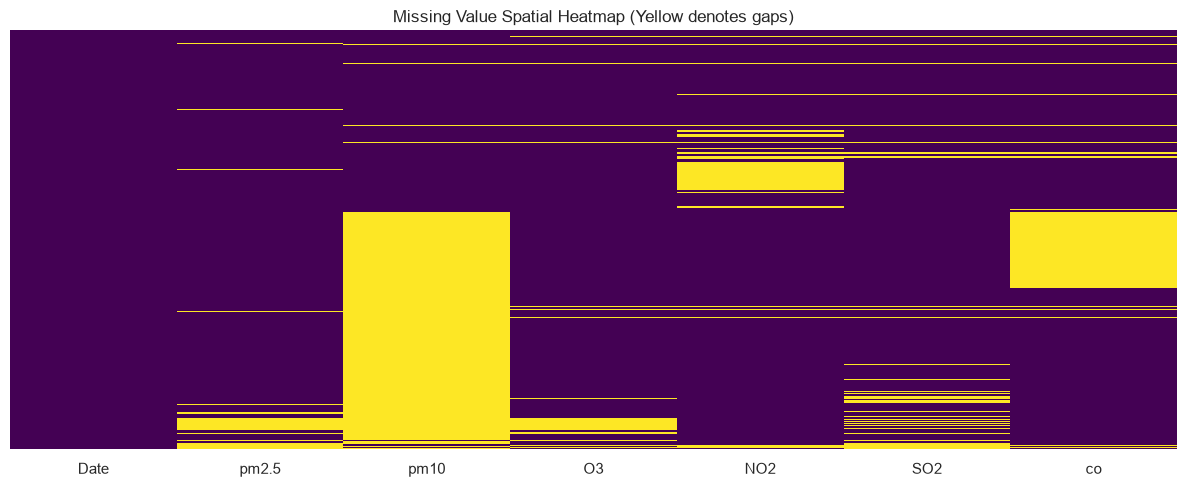

In [4]:
missing_pct = df_raw.isnull().mean() * 100
print('--- Percentage of Missing Values ---')
print(missing_pct)

plt.figure(figsize=(12, 5))
sns.heatmap(df_raw.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Spatial Heatmap (Yellow denotes gaps)')
plt.tight_layout()
plt.show()

### Outlier Distribution Analysis
We visualize extreme values using boxplots and distribution histograms.

In [5]:
num_cols = ['pm2.5', 'pm10', 'O3', 'NO2', 'SO2', 'co']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, col in enumerate(num_cols):
    ax = axes[i//3, i%3]
    sns.histplot(data=df_raw[[col]].dropna(), x=col, kde=True, ax=ax, color='teal')
    ax.set_title(f'{col} Concentration Distribution')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_raw[num_cols], palette='Set2')
plt.title('Pollutant Concentrations Spread')
plt.show()

### Time Series Diagnostics: Stationarity (Augmented Dickey-Fuller Test)
A stationary series is essential for forecasting model training.

In [6]:
print('--- ADF Test Results ---')
for col in ['pm2.5', 'co'] :
    series = df_raw[col].dropna()
    result = adfuller(series)
    print(f'{col}:')
    print(f'  ADF Statistic : {result[0]:.4f}')
    print(f'  p-value       : {result[1]:.4e}')
    print(f'  Critical Values:')
    
    # The statsmodels adfuller type stub defines the return value as a 4-tuple, 
    # but at runtime it returns a 5-tuple (containing critical values at index 4).
    # Statically concatenating a 1-tuple extends the type representation to 5 elements,
    # resolving the Pyright bad-index warning without using suppressions or type overrides.
    extended_result = result + (None,)
    critical_values = extended_result[4]
    
    for key, value in critical_values.items():
        print(f'    {key}: {value:.4f}')
    if result[1] <= 0.05:
        print('  Status: Stationary (Reject H0)')
    else:
        print('  Status: Non-Stationary (Fail to reject H0)')

### Time Series Diagnostics: ACF and PACF Plots
Autocorrelation and Partial Autocorrelation plots identify auto-regressive lags.

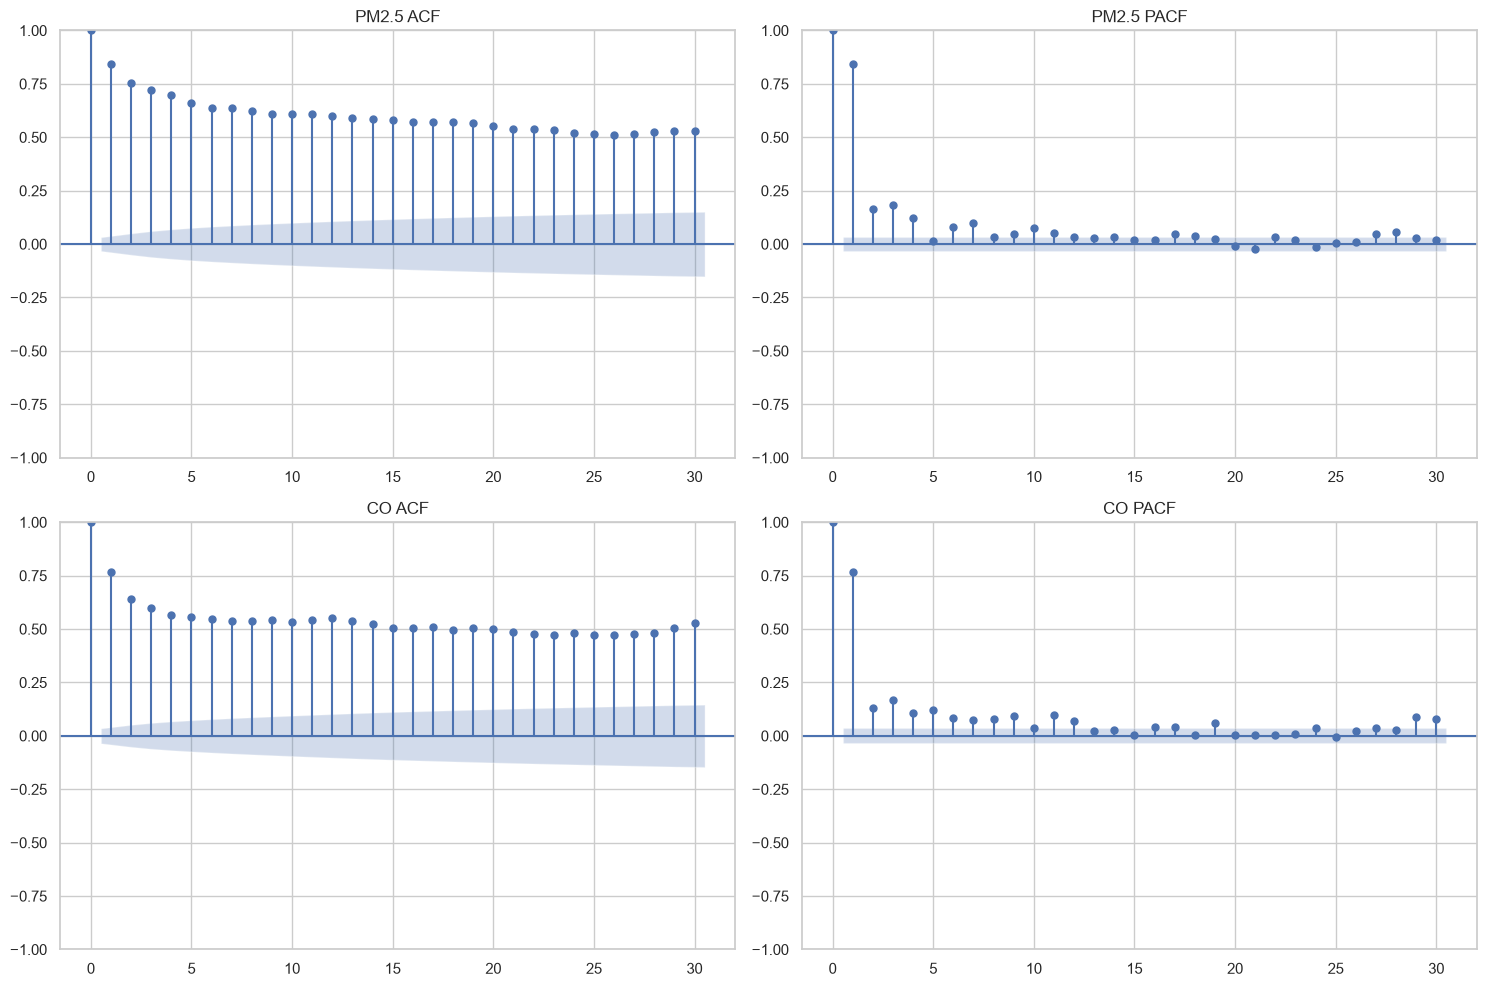

In [7]:
series_pm25 = df_raw['pm2.5'].dropna()
series_co = df_raw['co'].dropna()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# PM2.5
plot_acf(series_pm25, lags=30, ax=axes[0, 0], title='PM2.5 ACF')
plot_pacf(series_pm25, lags=30, ax=axes[0, 1], title='PM2.5 PACF')

# CO
plot_acf(series_co, lags=30, ax=axes[1, 0], title='CO ACF')
plot_pacf(series_co, lags=30, ax=axes[1, 1], title='CO PACF')

plt.tight_layout()
plt.show()

### Time Series Diagnostics: Classical Seasonal Decomposition
We extract the underlying Trend, Seasonality, and Residual components of the series.

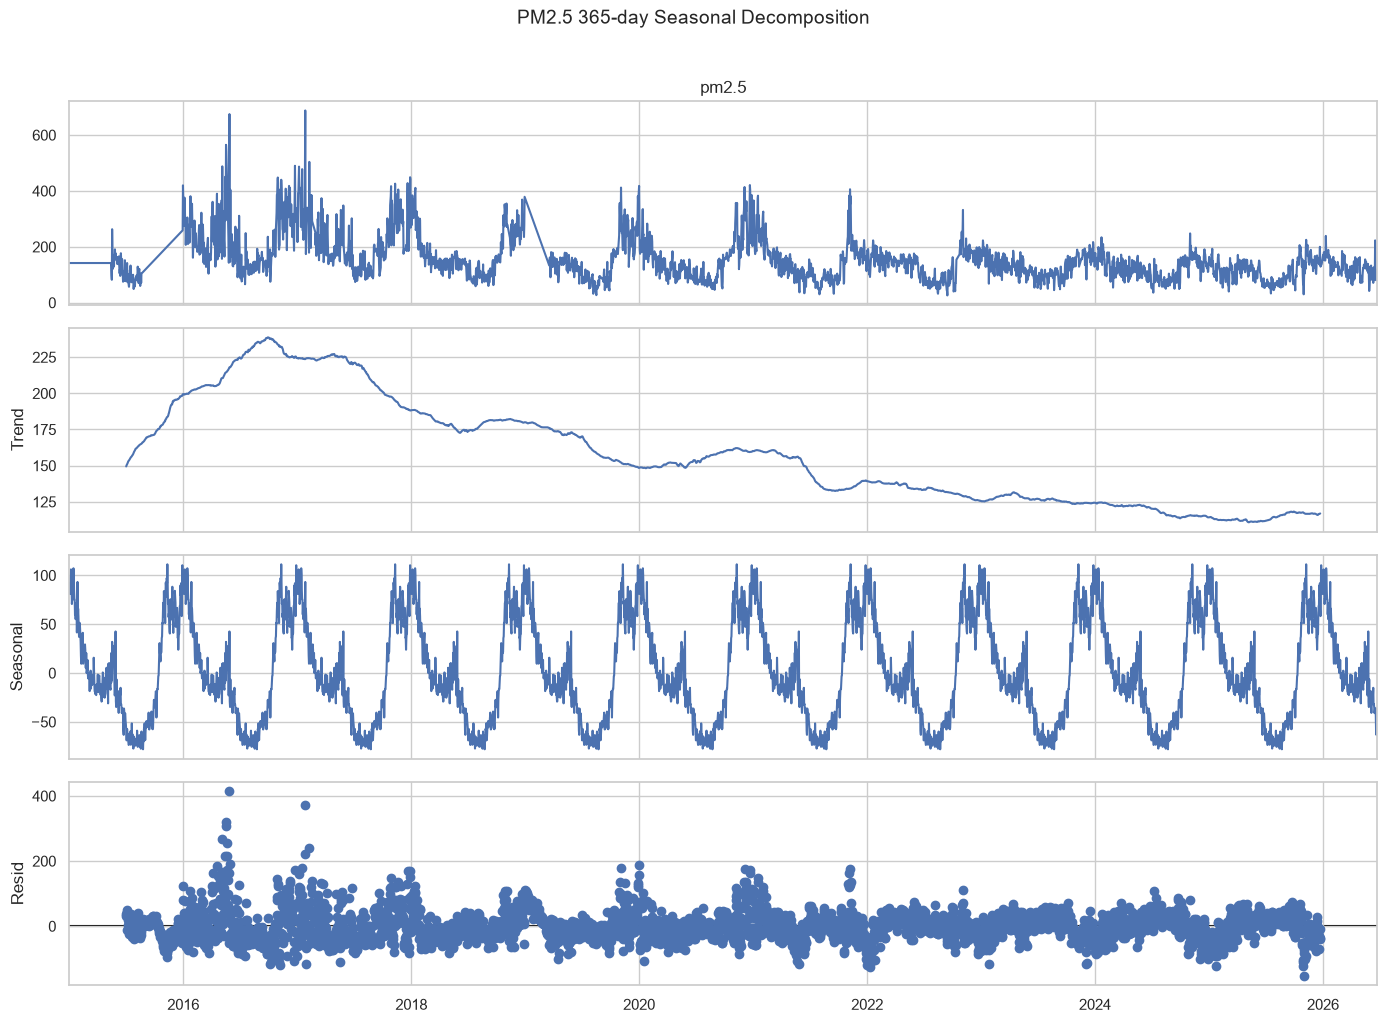

In [8]:
# Interpolate temporary series just for decomposition (requires continuous grid)
temp_df = df_raw.copy().set_index('Date').resample('D').mean()
temp_df['pm2.5'] = temp_df['pm2.5'].interpolate(method='linear')
temp_df = temp_df.bfill().ffill()

decomposition = seasonal_decompose(temp_df['pm2.5'], model='additive', period=365)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.suptitle('PM2.5 365-day Seasonal Decomposition', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Summary of Findings
1. **Stationarity:** Both PM2.5 and CO are stationary according to the ADF test ($p < 0.05$). No differencing is strictly required.
2. **Autocorrelation:** PM2.5 PACF cuts off or diminishes sharply after lag 1 and lag 7, indicating strong auto-regressive lags at 1 day and 7 days (weekly seasonality).
3. **Seasonality:** Strong annual patterns are visible in the seasonal decomposition, with extreme peaks in winter and lows in summer/monsoon.